# DB 에 무엇이 있나 — 수집 자료 지도

> `notebooks/01-데이터수집/03.DB에무엇이있나.ipynb` · 2026-09-02 · 이동원

---

## 이 노트북이 답하는 것

> **"우리가 지금 무슨 자료를 얼마나 갖고 있나?"**

팀원이 모델을 짜려면 먼저 이걸 알아야 합니다. 그런데 `data/krx_cache.db` 는
**저장소에 올라가지 않습니다** — KRX 이용약관 제11조 ②가 제3자 제공을 금지하고
이 저장소는 PUBLIC 이기 때문입니다.

그래서 이 노트북이 **DB 를 안 가진 사람에게 자료를 보여 주는 창구**입니다.
GitHub 웹에서 `.ipynb` 를 열면 아래 그림이 그대로 보입니다.

| 보여 주는 것 | 왜 |
|---|---|
| 표별 규모 | 무엇이 얼마나 있나 |
| **시점 지도** | 자료마다 **커버 구간이 다르다** — 조인하면 여기서 구멍이 난다 |
| 시세 연도별 | 16년이 고른가 · 생존 편향은 없나 |
| 재무 연도별 | **DART 가 어느 해부터 주는가** |
| 수집 대장 | "없는 것" 과 "안 받은 것" 의 구별 |

명령으로 같은 것을 보려면:

```bash
python scripts/check_db.py --log
```


## 0. 준비

⚠️ **읽기 전용(`mode=ro`)으로 엽니다.** 수집 배치가 도는 중에 쓰기로 열면 잠금을
다툽니다. 실제로 이 노트북을 만들 때도 DART 수집이 백그라운드로 돌고 있었습니다.


In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import font_manager

# 한글 폰트 — 설치된 것 중 먼저 찾아지는 것을 쓴다 (사람마다 OS 가 다르다)
설치됨 = {f.name for f in font_manager.fontManager.ttflist}
for 후보 in ("Malgun Gothic", "NanumGothic", "AppleGothic", "Gulim"):
    if 후보 in 설치됨:
        plt.rcParams["font.family"] = 후보
        break
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

DB = Path("../../data/krx_cache.db")
con = sqlite3.connect(f"file:{DB}?mode=ro", uri=True)


def 표(sql, params=()):
    return pd.read_sql_query(sql, con, params=params)


version = con.execute("PRAGMA user_version").fetchone()[0]
print(f"DB 크기   : {DB.stat().st_size / 1024 / 1024:,.0f} MB")
print(f"스키마    : v{version}")

DB 크기   : 1,646 MB
스키마    : v6


## 1. 표가 무엇 무엇 있나

표는 **세 무리**로 나뉩니다. 이 구별이 중요한 이유는 **자료 표만 보면 "왜 이게 없지?"
에 답할 수 없기** 때문입니다 — 그 답은 대장에 있습니다.

| 무리 | 표 | 무엇 |
|---|---|---|
| **자료** | `daily_price` · `index_price` · `dart_financial` | 실제 시세·지수·재무 |
| **대장** | `collect_log` · `fetch_log` · `index_fetch_log` | 무엇을 언제 받았나 |
| **살림** | `call_budget` · `raw_response` · `robots_cache` | 호출 예산·원문·크롤링 가드 |
| **반입** | `inbox_batch` · `inbox_accepted` · `inbox_quarantine` | 남의 자료를 들인 기록 |


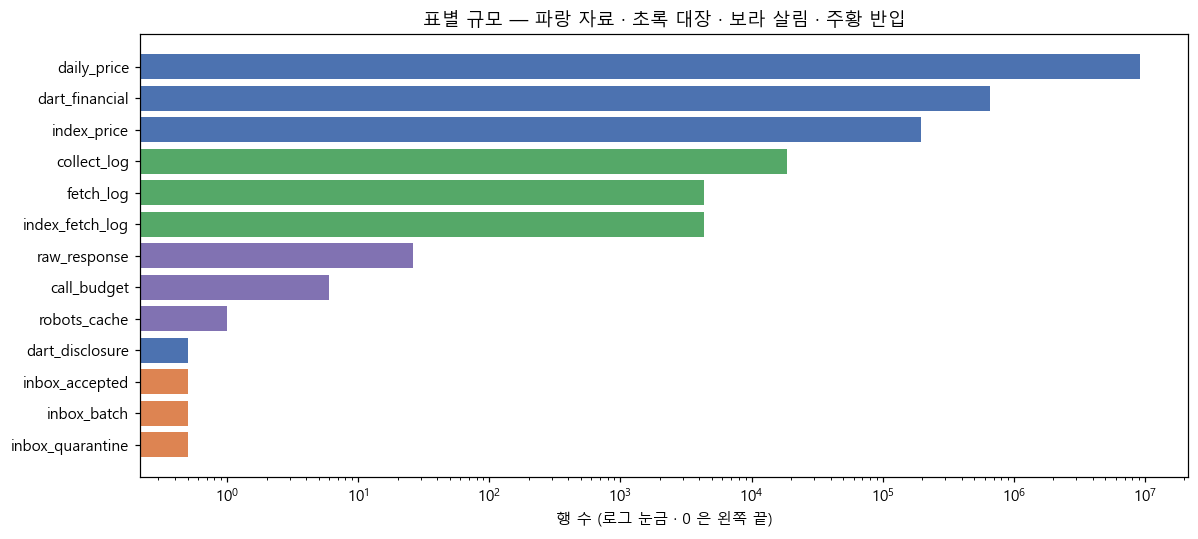

,표,행,무리
0,daily_price,9223644,자료
1,dart_financial,662933,자료
2,index_price,196119,자료
3,collect_log,18644,대장
4,fetch_log,4348,대장
5,index_fetch_log,4348,대장
6,raw_response,26,살림
7,call_budget,6,살림
8,robots_cache,1,살림
9,dart_disclosure,0,자료


In [2]:
줄 = []
for (t,) in con.execute(
    "SELECT name FROM sqlite_master WHERE type='table' "
    "AND name NOT LIKE 'sqlite_%' ORDER BY name"
):
    n = con.execute(f'SELECT COUNT(*) FROM "{t}"').fetchone()[0]
    줄.append({"표": t, "행": n})
표들 = pd.DataFrame(줄).sort_values("행", ascending=False)

무리 = {"daily_price": "자료", "index_price": "자료", "dart_financial": "자료",
        "dart_disclosure": "자료",
        "collect_log": "대장", "fetch_log": "대장", "index_fetch_log": "대장",
        "call_budget": "살림", "raw_response": "살림", "robots_cache": "살림"}
표들["무리"] = 표들["표"].map(lambda t: 무리.get(t, "반입"))
색 = {"자료": "#4C72B0", "대장": "#55A868", "살림": "#8172B2", "반입": "#DD8452"}

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(표들["표"], 표들["행"].clip(lower=0.5), color=표들["무리"].map(색))
ax.set_xscale("log")
ax.set_xlabel("행 수 (로그 눈금 · 0 은 왼쪽 끝)")
ax.set_title("표별 규모 — 파랑 자료 · 초록 대장 · 보라 살림 · 주황 반입", fontsize=12)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

표들.reset_index(drop=True)

**비어 있는 표가 있는 것은 정상입니다.** `inbox_*` 는 팀원이 파일을 건네줄 때
채워지고, `dart_disclosure` 는 공시 목록을 받을 때 채워집니다. 표를 먼저 만들어 두는
이유는 **스키마가 코드보다 늦으면 코드가 못 도는데**, 그 반대는 괜찮기 때문입니다.


## 2. 🔴 시점 지도 — 자료마다 커버 구간이 다르다

**이 그림이 이 노트북에서 가장 중요합니다.**

시세는 2010년부터 있는데 재무는 그렇지 않습니다. 이걸 모르고 조인하면 **재무가 없는
구간에서 조용히 행이 빠지거나** `NaN` 이 채워집니다. 어느 쪽이든 모델은 예외를 내지
않고 그냥 성능이 달라집니다.


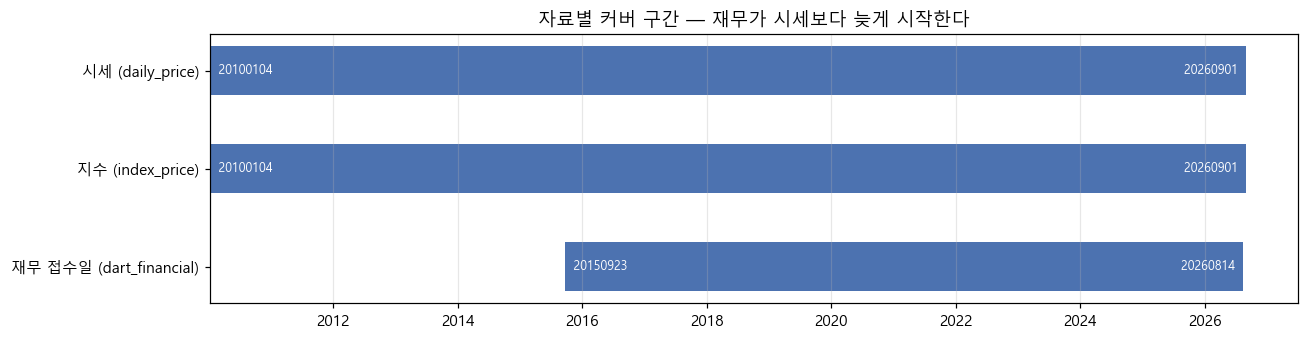

,이름,시작,끝
0,시세 (daily_price),20100104,20260901
1,지수 (index_price),20100104,20260901
2,재무 접수일 (dart_financial),20150923,20260814


In [3]:
구간 = []
for 이름, 표명, 칸 in [("시세 (daily_price)", "daily_price", "bas_dd"),
                       ("지수 (index_price)", "index_price", "bas_dd"),
                       ("재무 접수일 (dart_financial)", "dart_financial", "rcept_dt")]:
    lo, hi = con.execute(f'SELECT MIN("{칸}"), MAX("{칸}") FROM "{표명}"').fetchone()
    if lo:
        구간.append({"이름": 이름, "시작": lo, "끝": hi})

지도 = pd.DataFrame(구간)
지도["시작일"] = pd.to_datetime(지도["시작"], format="%Y%m%d")
지도["끝일"] = pd.to_datetime(지도["끝"], format="%Y%m%d")

fig, ax = plt.subplots(figsize=(12, 3.2))
for i, r in 지도.iterrows():
    ax.barh(r["이름"], r["끝일"] - r["시작일"], left=r["시작일"],
            color="#4C72B0", height=0.5)
    ax.text(r["시작일"], i, f"  {r['시작']}", va="center", ha="left",
            fontsize=8, color="white")
    ax.text(r["끝일"], i, f"{r['끝']}  ", va="center", ha="right",
            fontsize=8, color="white")

ax.set_title("자료별 커버 구간 — 재무가 시세보다 늦게 시작한다", fontsize=12)
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

지도[["이름", "시작", "끝"]]

재무가 시세보다 **늦게 시작하는 것**이 보입니다. 이유는 두 가지입니다.

1. **DART 가 전체계정을 주기 시작한 해**가 따로 있습니다 (아래 4절에서 실측)
2. 재무는 **결산기가 아니라 접수일**로 시점을 세웁니다 — FY2015 사업보고서는
   2016년 3월에 접수되므로, 접수일 기준으로는 2016년부터 쓸 수 있습니다

> 🔴 **결산기에 값을 붙이면 안 됩니다.** 2020년 4분기 실적은 2021년 3월에 나옵니다.
> 결산기에 붙이면 **석 달치 미래**를 학습에 넣고도 예외가 나지 않고 성능만 좋아집니다.


## 3. 시세 — 16년이 고른가

연도별 거래일 수는 대체로 **245~250일**이어야 합니다. 그리고 **종목 수가 오른쪽으로
갈수록 느는 것**이 중요합니다 — 지금 상장된 종목만 남기면 *생존 편향*이 생깁니다.


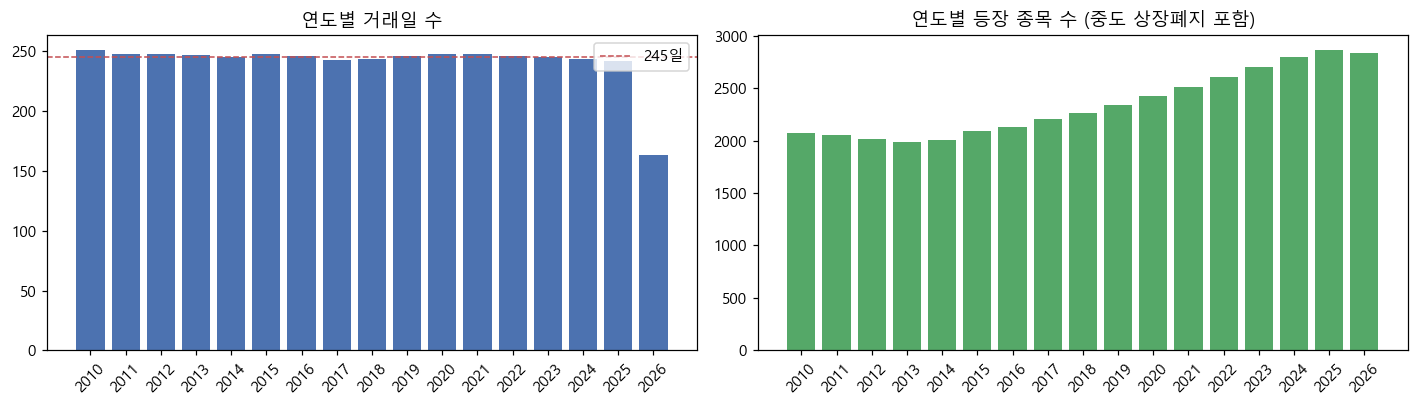

거래일 최소 163 · 최대 251
⚠️ 맨 오른쪽 해가 짧은 것은 정상입니다 — 아직 안 끝난 해입니다.


In [4]:
연도별 = 표("""
SELECT SUBSTR(bas_dd,1,4) AS 연도, COUNT(DISTINCT bas_dd) AS 거래일,
       COUNT(*) AS 행수, COUNT(DISTINCT code) AS 종목수
FROM daily_price GROUP BY 연도 ORDER BY 연도
""")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
axes[0].bar(연도별["연도"], 연도별["거래일"], color="#4C72B0")
axes[0].axhline(245, color="#C44E52", ls="--", lw=1, label="245일")
axes[0].set_title("연도별 거래일 수"); axes[0].legend()
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(연도별["연도"], 연도별["종목수"], color="#55A868")
axes[1].set_title("연도별 등장 종목 수 (중도 상장폐지 포함)")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

print(f"거래일 최소 {연도별['거래일'].min()} · 최대 {연도별['거래일'].max()}")
print("⚠️ 맨 오른쪽 해가 짧은 것은 정상입니다 — 아직 안 끝난 해입니다.")

## 4. 재무 — DART 는 어느 해부터 주는가

`fnlttSinglAcntAll`(단일회사 전체계정)은 **모든 해를 주지 않습니다.** 350종 × 16개년을
전부 요청해 보고 **어느 해부터 실제로 오는지 실측**했습니다.


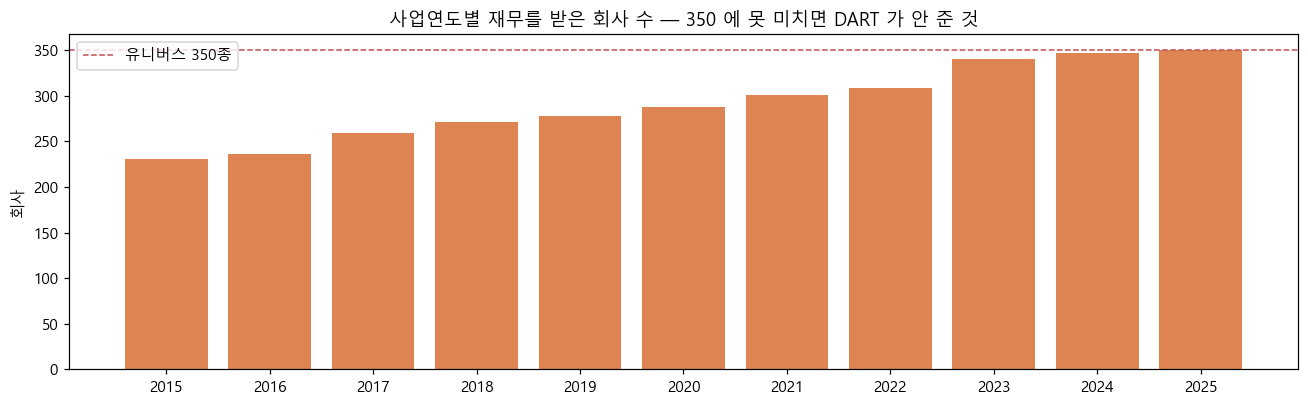

,사업연도,행수,회사수
0,2015,46428,231
1,2016,46817,236
2,2017,49127,259
3,2018,54257,271
4,2019,57511,278
5,2020,57228,288
6,2021,59291,301
7,2022,60831,308
8,2023,72378,340
9,2024,78098,347


In [5]:
재무연도 = 표("""
SELECT bsns_year AS 사업연도, COUNT(*) AS 행수,
       COUNT(DISTINCT corp_code) AS 회사수
FROM dart_financial GROUP BY bsns_year ORDER BY bsns_year
""")

fig, ax = plt.subplots(figsize=(12, 3.8))
ax.bar(재무연도["사업연도"].astype(str), 재무연도["회사수"], color="#DD8452")
ax.axhline(350, color="#C44E52", ls="--", lw=1, label="유니버스 350종")
ax.set_title("사업연도별 재무를 받은 회사 수 — 350 에 못 미치면 DART 가 안 준 것",
             fontsize=12)
ax.set_ylabel("회사")
ax.legend()
plt.tight_layout(); plt.show()

재무연도

In [6]:
# 받아 봤는데 없었던 것도 함께 본다 — '없다' 와 '안 받았다' 는 다르다
대장 = 표("""
SELECT status AS 상태, COUNT(*) AS 대상수
FROM collect_log WHERE source = 'dart_financial' GROUP BY status
""")
print(대장.to_string(index=False))
print()
print("ok    계정이 들어왔다")
print("empty 받아봤는데 없었다 — 상장 전·미제출. **미수집과 다르다**")
print("error 시도했는데 실패했다 (3회까지 다시 시도한다)")

   상태  대상수
empty 2391
   ok 3209

ok    계정이 들어왔다
empty 받아봤는데 없었다 — 상장 전·미제출. **미수집과 다르다**
error 시도했는데 실패했다 (3회까지 다시 시도한다)


`empty` 를 따로 세는 것이 핵심입니다. 이 구별이 없으면 **영원히 없을 자료를
실행할 때마다 다시 부르게 됩니다.** 350종 × 16개년이면 그 낭비가 매번 수천 콜입니다.


## 5. 재무제표 구분별 — 왜 SCE 가 가장 많은가

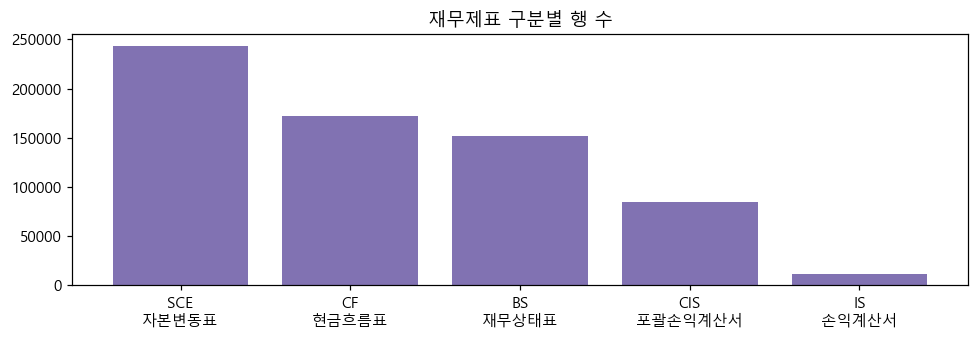

,구분,행수,설명
0,SCE,243238,자본변동표
1,CF,172448,현금흐름표
2,BS,151619,재무상태표
3,CIS,84042,포괄손익계산서
4,IS,11586,손익계산서


In [7]:
구분 = 표("""
SELECT sj_div AS 구분, COUNT(*) AS 행수 FROM dart_financial
GROUP BY sj_div ORDER BY 행수 DESC
""")
이름 = {"BS": "재무상태표", "IS": "손익계산서", "CIS": "포괄손익계산서",
        "CF": "현금흐름표", "SCE": "자본변동표"}
구분["설명"] = 구분["구분"].map(이름)

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.bar(구분["구분"] + "\n" + 구분["설명"], 구분["행수"], color="#8172B2")
ax.set_title("재무제표 구분별 행 수", fontsize=12)
plt.tight_layout(); plt.show()

구분

**자본변동표(SCE)가 가장 많은 것**이 자연스럽습니다. 자본변동표는
"자본금·주식발행초과금·이익잉여금·비지배지분…" **열마다 한 줄씩** 주기 때문입니다.

🔴 그래서 기본키에 `account_detail` 이 반드시 들어갑니다. 이 칸이 없으면 같은
`(계정명, ord)` 가 서로 다른 열인데도 하나로 뭉개져 **예외 없이 덮어써집니다.**
실측으로 전체의 **6.4%(22,436행)** 가 사라질 뻔했습니다.


## 6. 호출 예산 — 오늘 얼마나 썼나

출처마다 하루 한도가 있습니다. 넘기 전에 스스로 멈추려면 **부르기 전에** 세야 합니다.


In [8]:
예산 = 표("""
SELECT kst_date AS 날짜, source AS 출처, used AS 사용, daily_limit AS 한도
FROM call_budget ORDER BY kst_date DESC, source
""")
예산["비율(%)"] = (예산["사용"] / 예산["한도"] * 100).round(2)
예산

,날짜,출처,사용,한도,비율(%)
0,2026-09-02,dart,11645,20000,58.22
1,2026-09-02,krx,6,10000,0.06
2,2026-09-01,dart,1,20000,0.00
3,2026-09-01,krx,16,10000,0.16
4,2026-08-27,naver_search,15,25000,0.06
5,2026-08-26,krx,158,10000,1.58


## 정리

| 질문 | 어디서 답하나 |
|---|---|
| 무슨 자료가 얼마나 있나 | 1절 표별 규모 |
| **조인하면 어디서 구멍이 나나** | **2절 시점 지도** |
| 16년이 고른가 | 3절 |
| DART 가 어느 해부터 주나 | 4절 |
| 없는 것인가 안 받은 것인가 | 4절 수집 대장 |
| 오늘 한도를 얼마나 썼나 | 6절 |

명령으로도 같은 것을 봅니다.

```bash
python scripts/check_db.py --log     # 이 노트북의 표 부분
python scripts/check_data.py         # 시세 품질 게이트
python scripts/check_dart.py         # 재무 품질 게이트
```

### 기억할 것

1. **자료마다 커버 구간이 다르다** — 조인 전에 2절을 본다
2. **재무는 결산기가 아니라 접수일로 시점을 세운다**
3. **"없다" 와 "안 받았다" 는 다르다** — 대장이 그 구별을 들고 있다


In [9]:
con.close()
print("닫았습니다.")

닫았습니다.
